

# Практическое задание №2: «Умный детектор без ML»
**Студент:** [Ваше Грачев Александр Андреевич / ИДБ-25-06]  
**Цель работы:** Сделать детектор аномалий гибче без использования алгоритмов ML — с учётом статистики ($k\sigma$), скорости изменения параметров (производной) и комбинации нескольких признаков сразу.

---
## 1. Введение и постановка проблемы
В лабораторной работе №1 использовался простой детектор с жёсткими порогами. Однако у спутника ДЗЗ есть **4 режима работы**: `attitude_control`, `standby`, `imaging`, `downlink`. В каждом из них нормальные показатели тока, напряжения и температуры кардинально отличаются.

Загрузим данные и исследуем описательную статистику по каждому режиму:


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Включение отображения графиков в ноутбуке
%matplotlib inline

# Загрузка датасета
df = pd.read_csv('telemetry_dzz_sem1.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Загружено записей: {len(df)}")
df.head()

Загружено записей: 720


,timestamp,temperature,voltage,current,angular_velocity,mode
0,2026-09-07 08:00:00,23.94,28.24,1.44,0.033,standby
1,2026-09-07 08:01:00,24.11,28.13,1.48,0.022,standby
2,2026-09-07 08:02:00,24.23,28.23,1.48,0.039,standby
3,2026-09-07 08:03:00,24.79,28.22,1.41,0.013,standby
4,2026-09-07 08:04:00,24.77,28.29,1.48,0.024,standby


---
## 2. Этап 1. Анализ нормальных показателей по режимам работы (`mode`)

### 📌 Логика и методология
Главный вопрос этапа: **«Может ли одно и то же значение быть нормальным в одном режиме и подозрительным в другом?»**  
Спутник дистанционного зондирования Земли работает в разных состояниях (`standby`, `imaging`, `downlink`, `attitude_control`). Для каждого режима характерно своё энергопотребление и тепловыделение.

Для определения «нормы» в каждом режиме мы группируем данные по столбцу `mode` и рассчитываем описательную статистику (среднее, минимум, максимум, стандартное отклонение) с помощью функции `groupby().describe()`.

In [12]:
# 1. Анализируем параметры в разрезе режимов работы
print("=== СТАТИСТИКА ТЕМПЕРАТУРЫ ПО РЕЖИМАМ ===")
display(df.groupby('mode')['temperature'].describe())

print("\n=== СТАТИСТИКА ЭНЕРГОПОТРЕБЛЕНИЯ (ТОК, A) ПО РЕЖИМАМ ===")
display(df.groupby('mode')['current'].describe())

=== СТАТИСТИКА ТЕМПЕРАТУРЫ ПО РЕЖИМАМ ===


,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
attitude_control,100.0,29.054300,0.861798,26.62,28.5150,29.195,29.690,30.85
downlink,120.0,32.384000,8.914038,27.44,28.8600,29.590,31.490,65.16
imaging,160.0,38.831063,6.763547,32.50,36.2050,37.480,38.905,68.23
standby,340.0,24.170647,1.880855,20.67,22.6375,24.265,25.720,28.27



=== СТАТИСТИКА ЭНЕРГОПОТРЕБЛЕНИЯ (ТОК, A) ПО РЕЖИМАМ ===


,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
attitude_control,100.0,5.659500,0.237573,5.14,5.4900,5.680,5.8075,6.16
downlink,120.0,3.893417,1.826895,2.68,3.0600,3.270,3.5425,10.30
imaging,160.0,5.219125,1.059717,4.06,4.7775,5.030,5.2800,10.32
standby,340.0,1.469471,0.113905,1.23,1.3900,1.475,1.5500,1.74


> **Промежуточный вывод к Этапу 1:**
> Различие параметров между режимами огромно.
> - В режиме ожидания (`standby`) средняя температура составляет **24.17 °C**, а ток — всего **1.47 А**.
> - В режиме съемки Земли (`imaging`) нагрузка возрастает: средняя температура поднимается до **38.83 °C**, а ток — до **5.22 А**.
>
> **Ответ на главный вопрос:** Да, температура 38 °C абсолютно нормальна для режима `imaging`, но для режима `standby` это явный нештатный нагрев.
---
## 3. Этап 2. Статистический детектор (Правило $k \cdot \sigma$)

### 📌 Логика и методология
Вместо фиксированных порогов используем глобальное математическое ожидание (среднее $\mu$) и стандартное отклонение ($\sigma$) для параметра `temperature`. Значение считается подозрительным, если оно отклоняется от среднего более чем на $k$ стандартных отклонений:
$$\vert{}X - \mu\vert{} > k \cdot \sigma$$

Мы исследуем три варианта границы чувствительности: $1\sigma$, $2\sigma$ и $3\sigma$.

In [14]:
# Вычисление глобального среднего и стандартного отклонения
mean_temp = df['temperature'].mean()
std_temp = df['temperature'].std()

# Расчет аномалий для 1, 2 и 3 сигма
df['stat_1sigma'] = (abs(df['temperature'] - mean_temp) > 1 * std_temp).astype(int)
df['stat_2sigma'] = (abs(df['temperature'] - mean_temp) > 2 * std_temp).astype(int)
df['stat_3sigma'] = (abs(df['temperature'] - mean_temp) > 3 * std_temp).astype(int)

print(f"Глобальное среднее по температуре: {mean_temp:.2f} °C")
print(f"Стандартное отклонение (std):     {std_temp:.2f} °C\n")

print(f"Количество аномалий при 1σ (порог {mean_temp + std_temp:.2f} °C): {df['stat_1sigma'].sum()}")
print(f"Количество аномалий при 2σ (порог {mean_temp + 2*std_temp:.2f} °C): {df['stat_2sigma'].sum()}")
print(f"Количество аномалий при 3σ (порог {mean_temp + 3*std_temp:.2f} °C): {df['stat_3sigma'].sum()}")

Глобальное среднее по температуре: 29.48 °C
Стандартное отклонение (std):     7.70 °C

Количество аномалий при 1σ (порог 37.17 °C): 146
Количество аномалий при 2σ (порог 44.87 °C): 19
Количество аномалий при 3σ (порог 52.57 °C): 19


>  **Промежуточный вывод к Этапу 2:**
> Увеличение коэффициента $\sigma$ делает детектор менее «паникёрским». Порог $1\sigma$ захватывает 146 измерений (включая рабочие штатные колебания). Порог $2\sigma$ и $3\sigma$ фиксирует только 19 аномалий.
> **Недостаток подхода:** Поскольку среднее считалось по всему датасету без учета `mode`, статистический детектор ловит только экстремальные пики в режиме `imaging`, но пропускает перегрев в режиме `standby`.
---
## 4. Этап 3. Детектор быстрых изменений (`.diff()`)

### 📌 Логика и методология
Аномалией может быть не само высокое значение, а **скорость его изменения**. Плавный прогрев оборудования нормален, но скачок температуры или проседания напряжения за короткий промежуток времени сигнализирует об аварийном сбое.

Используем функцию `df['temperature'].diff()`, чтобы посчитать абсолютную разность между соседними измерениями $t_i - t_{i-1}$. Задаем порог резкого скачка в **1.5 °C за 1 минуту**.

In [15]:
# Расчет разницы между соседними измерениями
df['temp_diff'] = df['temperature'].diff().abs()

# Определение аномалии при скачке > 1.5 °C
thresh_diff = 1.5
df['anomaly_diff'] = (df['temp_diff'] > thresh_diff).astype(int)

print(f"Найдено точек с резким изменением температуры (> {thresh_diff} °C/мин): {df['anomaly_diff'].sum()}")

Найдено точек с резким изменением температуры (> 1.5 °C/мин): 35


---
## 5. Этап 4. Комбинированный балльный детектор (Multi-feature Score)

### 📌 Логика и методология
Чтобы снизить риск ложных срабатываний из-за сбоя одного датчика, вводится **оценка подозрительности (score)**. Каждое отклонение добавляет 1 балл:
1. Высокая температура (`temp > 35.0 °C`)
2. Низкое напряжение (`voltage < 27.5 В`)
3. Высокий ток (`current > 5.5 А`)
4. Высокая угловая скорость (`angular_velocity > 0.1`)

Если состояние суммарно набирает **2 и более баллов**, интервал объявляется потенциально нештатным (`anomaly_comb = 1`).

In [16]:
# Расчет отдельных флагов подозрительности
c_temp = (df['temperature'] > 35.0).astype(int)
c_volt = (df['voltage'] < 27.5).astype(int)
c_curr = (df['current'] > 5.5).astype(int)
c_ang  = (df['angular_velocity'] > 0.1).astype(int)

# Вычисление итогового балла
df['score'] = c_temp + c_volt + c_curr + c_ang

# Состояние считается аномальным, если набрано 2+ балла
df['anomaly_det3'] = (df['score'] >= 2).astype(int)

# Детектор №1 для сравнения (Жёсткие пороги - срабатывание при ЛЮБОМ 1 флаге)
df['anomaly_det1'] = (c_temp | c_volt | c_curr | c_ang).astype(int)

# Детектор №2 (Статистика 2σ)
df['anomaly_det2'] = df['stat_2sigma']

print("=== СРАВНЕНИЕ КОЛИЧЕСТВА СРАБАТЫВАНИЙ ДЕТЕКТОРОВ ===")
print(f"Детектор №1 (Жёсткие пороги, любая аномалия): {df['anomaly_det1'].sum()}")
print(f"Детектор №2 (Статистический 2σ):               {df['anomaly_det2'].sum()}")
print(f"Детектор №3 (Комбинация признаков, score>=2):  {df['anomaly_det3'].sum()}")

=== СРАВНЕНИЕ КОЛИЧЕСТВА СРАБАТЫВАНИЙ ДЕТЕКТОРОВ ===
Детектор №1 (Жёсткие пороги, любая аномалия): 277
Детектор №2 (Статистический 2σ):               19
Детектор №3 (Комбинация признаков, score>=2):  199


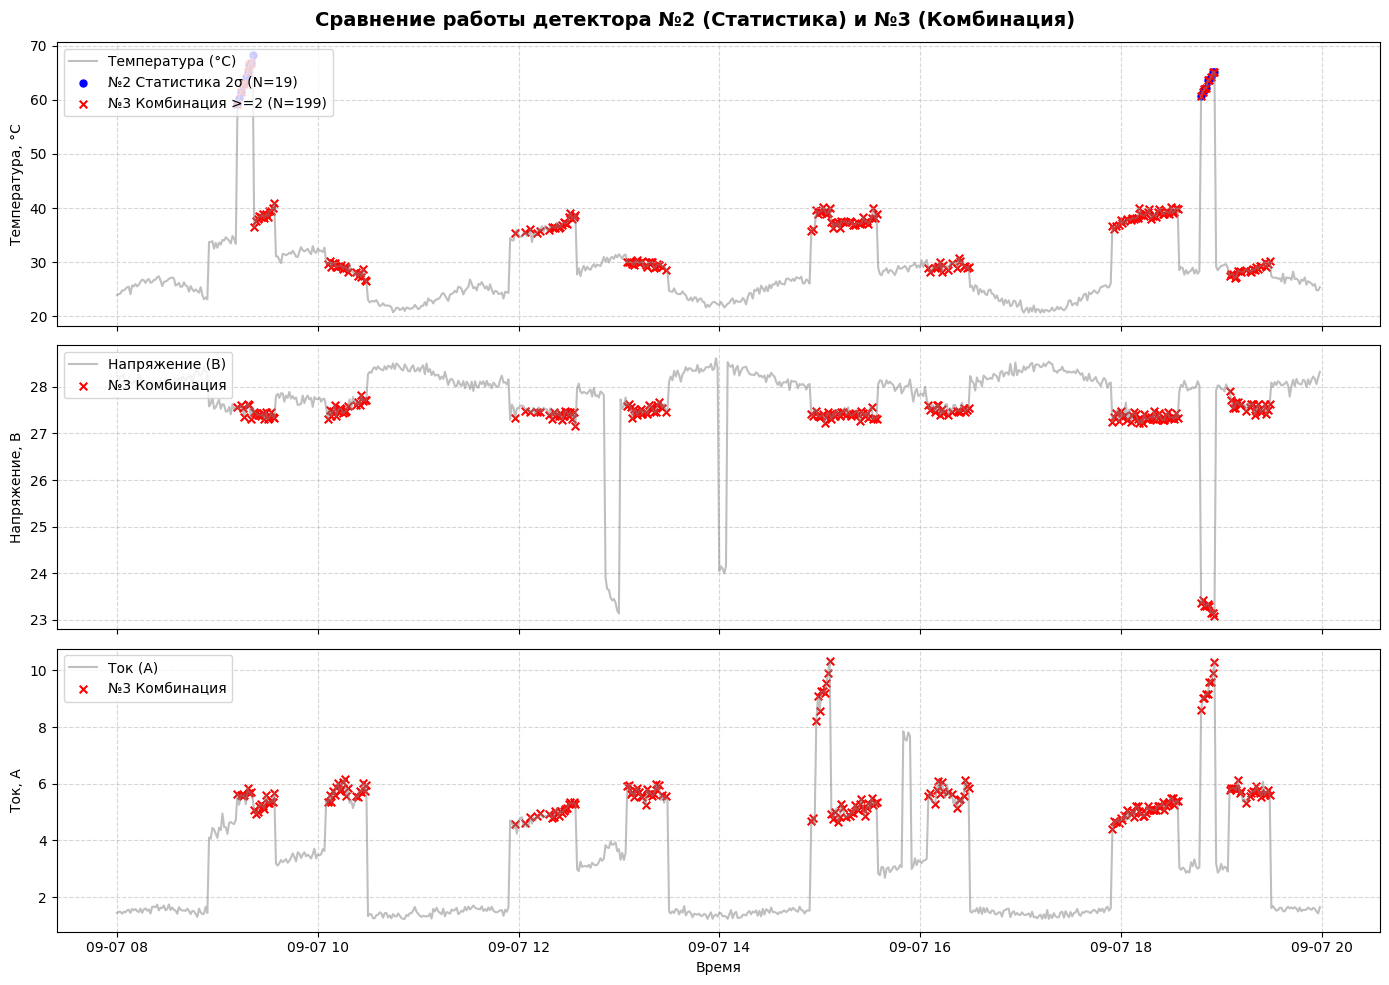

In [17]:
# Построение графиков телеметрии с отметками аномалий
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Сравнение работы детектора №2 (Статистика) и №3 (Комбинация)', fontsize=14, fontweight='bold')

anom2 = df[df['anomaly_det2'] == 1]
anom3 = df[df['anomaly_det3'] == 1]

# Температура
axes[0].plot(df['timestamp'], df['temperature'], color='gray', alpha=0.5, label='Температура (°C)')
axes[0].scatter(anom2['timestamp'], anom2['temperature'], color='blue', s=25, label=f'№2 Статистика 2σ (N={len(anom2)})')
axes[0].scatter(anom3['timestamp'], anom3['temperature'], color='red', marker='x', s=30, label=f'№3 Комбинация >=2 (N={len(anom3)})')
axes[0].set_ylabel('Температура, °C')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')

# Напряжение
axes[1].plot(df['timestamp'], df['voltage'], color='gray', alpha=0.5, label='Напряжение (В)')
axes[1].scatter(anom3['timestamp'], anom3['voltage'], color='red', marker='x', s=30, label='№3 Комбинация')
axes[1].set_ylabel('Напряжение, В')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper left')

# Ток
axes[2].plot(df['timestamp'], df['current'], color='gray', alpha=0.5, label='Ток (А)')
axes[2].scatter(anom3['timestamp'], anom3['current'], color='red', marker='x', s=30, label='№3 Комбинация')
axes[2].set_ylabel('Ток, А')
axes[2].set_xlabel('Время')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 6. Итоговая таблица и ответы на вопросы (Этапы 6, 7, 8)

### Сравнительная таблица результатов (Пункт 6)

| Детектор | Аномалий | Используемые признаки | Главный недостаток |
| :--- | :---: | :--- | :--- |
| **№1 Жёсткие пороги** | **277** | Выход хотя бы одного параметра за фиксированную границу (`temp>35`, `volt<27.5`, `curr>5.5`) | **Огромное количество ложных тревог.** Нарушения фиксируются при обычной работе спутника во время съемки (`imaging`). |
| **№2 Статистика** | **19** | Отклонение температуры от среднего более чем на $2\sigma$ ($> 44.87^\circ\text{C}$) | **Не учитывает контекст режимов.** Глобальное среднее смазывает норму, из-за чего локальный перегрев в режиме `standby` пропускается. |
| **№3 Комбинация** | **199** | Одновременное совпадение двух и более подозрительных признаков (`score >= 2`) | **Ручные границы.** Все пороги задаются экспертом вручную и не адаптируются автоматически под смену состояния аппарата. |

---

### Ответы на вопросы для вывода (Пункт 7)

1. **Почему одно и то же значение может быть нормальным в одном режиме и подозрительным в другом?**  
   Из-за различий в энергопотреблении оборудования. Во время съёмки (`imaging`) активно работает камера, возрастает ток и температура (норма до 39 °C). В режиме ожидания (`standby`) аппаратура отключена, поэтому показатель 39 °C — это явная авария или короткое замыкание.

2. **Как влияет выбор $\sigma$ на количество обнаруженных аномалий?**  
   Чем больше коэффициент $\sigma$, тем уже диапазон считающихся аномалиями значений. При $1\sigma$ обнаруживается 146 аномалий (избыточно), а при $2\sigma$ и $3\sigma$ — всего 19 наиболее критических выбросов.

3. **Почему резкое изменение параметра может быть важнее его абсолютного значения?**  
   Потому что скачок температуры за секунды указывает на аварийную ситуацию (например, пробой изоляции или сбой системы охлаждения), даже если сама температура еще не успела превысить формальный верхний порог.

4. **Что даёт комбинация нескольких признаков?**  
   Повышает надёжность. Случайный сбой одного датчика не приведет к ложному вызову бригады, но одновременный скачок тока, просадка напряжения и нагрев точно подтверждают нештатную ситуацию.

5. **Какие проблемы всё ещё остаются у такого детектора?**  
   Человек всё ещё должен **вручную придумывать правила и подбирать пороги**. Алгоритм не умеет обучаться сам.

---
### Переход к машинному обучению (Пункт 8)
Текущие эксперименты показали, что вручную описать все взаимосвязи режимов, скачков и комбинированных порогов невозможно. Следующим логическим шагом является переход к **Машинному Обучению (ML)**, где алгоритм сам проанализирует многомерные данные и построит гибкую модель нормы для каждого режима.